#####git

In [ ]:
import os
from google.colab import userdata

# 1. Limpeza preventiva (evita o efeito inception)
!rm -rf /content/projeto

# 2. Configuração de Identidade
!git config --global user.email "be.ctrindade@gmail.com"
!git config --global user.name "TrindadeBC"

# 3. Clone Seguro
TOKEN = userdata.get('GITHUB_TOKEN')
REPO_URL = f"https://{TOKEN}@github.com/TrindadeBc/cd2-projeto-3.git"
!git clone {REPO_URL} /content/projeto

# 4. Entra na pasta
%cd /content/projeto


In [60]:
# Copia o Notebook
!cp "/content/Projeto_CD2_Analise_Epidem_DATASUS.ipynb" .

# Copia as Anotações (usamos aspas por causa dos caracteres especiais)
!cp "/content/anotações.txt" .

# Lista para confirmar se os dois estão lá
!ls

In [ ]:
# 1. Adiciona as mudanças
!git add .

# 2. Registra a alteração com uma mensagem
!git commit -m "Merge na lista de colunas para apagar(precisa revisar) e de anotações.txt atualizado "

# 3. Envia para o GitHub (na branch main)
!git push origin patch-1

#Baixar e extrair os dados
#(pode ser usada para dar reset no CSV)

In [45]:
# Baixa o arquivo zipado diretamente do servidor do Ministério da Saúde
!wget "https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/SINAN/Dengue/csv/DENGBR25.csv.zip" -O dengue_2025.zip

# Descompacta o arquivo na pasta 'dados_dengue'
!unzip dengue_2025.zip -d /content/dados_dengue

# Remove o arquivo zip para limpar o espaço em disco
!rm dengue_2025.zip

# Para recriar o RESETAR df sem precisar executar as celulas apenas de relatório que demoram de ser executadas.
df = pd.read_csv('/content/dados_dengue/DENGBR25.csv', sep=',', low_memory=False)


--2026-03-01 04:34:44--  https://s3.sa-east-1.amazonaws.com/ckan.saude.gov.br/SINAN/Dengue/csv/DENGBR25.csv.zip
Resolving s3.sa-east-1.amazonaws.com (s3.sa-east-1.amazonaws.com)... 3.5.232.252, 16.12.1.4, 3.5.233.79, ...
Connecting to s3.sa-east-1.amazonaws.com (s3.sa-east-1.amazonaws.com)|3.5.232.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 34127288 (33M) [binary/octet-stream]
Saving to: ‘dengue_2025.zip’

dengue_2025.zip     100%[===================>]  32.55M  13.1MB/s    in 2.5s    

2026-03-01 04:34:47 (13.1 MB/s) - ‘dengue_2025.zip’ saved [34127288/34127288]

Archive:  dengue_2025.zip
replace /content/dados_dengue/DENGBR25.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/dados_dengue/DENGBR25.csv  


#Célula de Mapeamento e Diagnóstico Ampliado (Geral - Percentual) (Instâncias, NaN e Ignorados)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ==============================================================================
# 1. CARREGAMENTO DOS DADOS
# ==============================================================================
df = pd.read_csv('/content/dados_dengue/DENGBR25.csv', sep=',', low_memory=False)

# ==============================================================================
# 2. ESTATÍSTICAS DE VOLUME E REDUNDÂNCIA
# ==============================================================================
n_linhas, n_colunas = df.shape
print(f"--- ESTATÍSTICAS DE VOLUME ---")
print(f"Total de Instâncias (Linhas): {n_linhas}")
print(f"Total de Atributos (Colunas): {n_colunas}\n")

# Correção: Removemos o dropna=False para que colunas com 1 único valor + NaNs sejam pegas
colunas_constantes = [col for col in df.columns if df[col].nunique() == 1]

# Monta o relatório pegando o valor real (ignorando os NaNs)
relatorio_constantes = []
for col in colunas_constantes:
    valor_unico = df[col].dropna().unique()[0] if not df[col].dropna().empty else np.nan
    relatorio_constantes.append({'Atributo': col, 'Valor Fixo': valor_unico})

print(f"--- RELATÓRIO DE ATRIBUTOS REDUNDANTES ({len(colunas_constantes)} colunas) ---")
print("Estes campos não possuem variância e devem ser removidos no pré-processamento.")
print(pd.DataFrame(relatorio_constantes).to_string(index=False))
print("\n")

# ==============================================================================
# 3. DICIONÁRIO DE TRADUÇÃO COMPLETO (SINAN DAENT)
# ==============================================================================
map_nomes_colunas = {
    'TP_NOT': 'Tipo de Notificação', 'ID_AGRAVO': 'Agravo (Doença)', 'DT_NOTIFIC': 'Data da Notificação',
    'SEM_NOT': 'Semana Epidem. da Notificação', 'NU_ANO': 'Ano da Notificação', 'SG_UF_NOT': 'UF de Notificação',
    'ID_MUNICIP': 'Município de Notificação', 'ID_REGIONA': 'Regional de Saúde (Notificação)',
    'ID_UNIDADE': 'Unidade de Saúde Notificadora', 'DT_SIN_PRI': 'Data dos Primeiros Sintomas',
    'SEM_PRI': 'Semana Epidem. dos Primeiros Sintomas', 'ANO_NASC': 'Ano de Nascimento', 'NU_IDADE_N': 'Idade',
    'CS_SEXO': 'Sexo', 'CS_GESTANT': 'Gestante', 'CS_RACA': 'Raça/Cor', 'CS_ESCOL_N': 'Escolaridade',
    'SG_UF': 'UF de Residência', 'ID_MN_RESI': 'Município de Residência', 'ID_RG_RESI': 'Regional de Saúde (Residência)',
    'ID_PAIS': 'País de Residência', 'DT_INVEST': 'Data da Investigação', 'ID_OCUPA_N': 'Ocupação',
    'FEBRE': 'Sintoma: Febre', 'MIALGIA': 'Sintoma: Mialgia', 'CEFALEIA': 'Sintoma: Cefaleia',
    'EXANTEMA': 'Sintoma: Exantema', 'VOMITO': 'Sintoma: Vômito', 'NAUSEA': 'Sintoma: Náusea',
    'DOR_COSTAS': 'Sintoma: Dor nas Costas', 'CONJUNTVIT': 'Sintoma: Conjuntivite', 'ARTRITE': 'Sintoma: Artrite',
    'ARTRALGIA': 'Sintoma: Artralgia Intensa', 'PETEQUIA_N': 'Sintoma: Petéquias', 'LEUCOPENIA': 'Sintoma: Leucopenia',
    'LACO': 'Sintoma: Prova do Laço', 'DOR_RETRO': 'Sintoma: Dor Retroorbital', 'DIABETES': 'Comorbidade: Diabetes',
    'HEMATOLOG': 'Comorbidade: Doenças Hematológicas', 'HEPATOPAT': 'Comorbidade: Hepatopatias',
    'RENAL': 'Comorbidade: Doença Renal Crônica', 'HIPERTENSA': 'Comorbidade: Hipertensão Arterial',
    'ACIDO_PEPT': 'Comorbidade: Doença Ácido-Péptica', 'AUTO_IMUNE': 'Comorbidade: Doença Autoimune',
    'DT_CHIK_S1': 'Data Coleta Chikungunya (Soro 1)', 'DT_CHIK_S2': 'Data Coleta Chikungunya (Soro 2)',
    'DT_PRNT': 'Data Coleta Exame PRNT', 'RES_CHIKS1': 'Resultado Chikungunya (Soro 1)',
    'RES_CHIKS2': 'Resultado Chikungunya (Soro 2)', 'RESUL_PRNT': 'Resultado Exame PRNT',
    'DT_SORO': 'Data Coleta Sorologia Dengue', 'RESUL_SORO': 'Resultado Sorologia Dengue',
    'DT_NS1': 'Data Coleta Exame NS1', 'RESUL_NS1': 'Resultado Exame NS1', 'DT_VIRAL': 'Data Coleta Isolamento Viral',
    'RESUL_VI_N': 'Resultado Isolamento Viral', 'DT_PCR': 'Data Coleta RT-PCR', 'RESUL_PCR_': 'Resultado RT-PCR',
    'SOROTIPO': 'Sorotipo do Vírus', 'HISTOPA_N': 'Resultado Histopatologia', 'IMUNOH_N': 'Resultado Imunohistoquímica',
    'HOSPITALIZ': 'Ocorreu Hospitalização?', 'DT_INTERNA': 'Data de Internação', 'UF': 'UF de Internação/Infecção',
    'MUNICIPIO': 'Município de Internação/Infecção', 'TPAUTOCTO': 'Caso Autóctone?', 'COUFINF': 'UF Provável da Infecção',
    'COPAISINF': 'País Provável da Infecção', 'COMUNINF': 'Município Provável da Infecção', 'CLASSI_FIN': 'Classificação Final',
    'CRITERIO': 'Critério de Confirmação', 'DOENCA_TRA': 'Doença Relacionada ao Trabalho',
    'CLINC_CHIK': 'Apresentação Clínica Chikungunya', 'EVOLUCAO': 'Evolução do Caso', 'DT_OBITO': 'Data do Óbito',
    'DT_ENCERRA': 'Data do Encerramento', 'ALRM_HIPOT': 'Alarme: Hipotensão', 'ALRM_PLAQ': 'Alarme: Queda de Plaquetas',
    'ALRM_VOM': 'Alarme: Vômitos Persistentes', 'ALRM_SANG': 'Alarme: Sangramento de Mucosa',
    'ALRM_HEMAT': 'Alarme: Aumento de Hematócrito', 'ALRM_ABDOM': 'Alarme: Dor Abdominal Intensa',
    'ALRM_LETAR': 'Alarme: Letargia/Irritabilidade', 'ALRM_HEPAT': 'Alarme: Hepatomegalia',
    'ALRM_LIQ': 'Alarme: Acúmulo de Líquidos', 'DT_ALRM': 'Data Início Sinais de Alarme',
    'GRAV_PULSO': 'Grave: Pulso Débil', 'GRAV_CONV': 'Grave: PA Convergente', 'GRAV_ENCH': 'Grave: Enchimento Capilar Lento',
    'GRAV_INSUF': 'Grave: Insuficiência Respiratória', 'GRAV_TAQUI': 'Grave: Taquicardia',
    'GRAV_EXTRE': 'Grave: Extremidades Frias', 'GRAV_HIPOT': 'Grave: Hipotensão Arterial Tardia',
    'GRAV_HEMAT': 'Grave: Hematêmese', 'GRAV_MELEN': 'Grave: Melena', 'GRAV_METRO': 'Grave: Metrorragia Volumosa',
    'GRAV_SANG': 'Grave: Sangramento do SNC', 'GRAV_AST': 'Grave: AST/ALT > 1.000', 'GRAV_MIOC': 'Grave: Miocardite',
    'GRAV_CONSC': 'Grave: Alteração da Consciência', 'GRAV_ORGAO': 'Grave: Falência de Outros Órgãos',
    'DT_GRAV': 'Data Início Dengue Grave', 'MANI_HEMOR': 'Manifestações Hemorrágicas', 'EPISTAXE': 'Hemorragia: Epistaxe',
    'GENGIVO': 'Hemorragia: Gengivorragia', 'METRO': 'Hemorragia: Metrorragia', 'PETEQUIAS': 'Hemorragia: Petéquias',
    'HEMATURA': 'Hemorragia: Hematúria', 'SANGRAM': 'Hemorragia: Sangramento Gastrointestinal',
    'LACO_N': 'Hemorragia: Prova do Laço Positiva', 'PLASMATICO': 'Extravasamento Plasmático',
    'EVIDENCIA': 'Extravasamento Evidenciado Por', 'PLAQ_MENOR': 'Plaquetas: Menor Valor',
    'CON_FHD': 'Caso de Febre Hemorrágica (FHD/SCD)', 'COMPLICA': 'Dengue com Complicações',
    'TP_SISTEMA': 'Tipo de Sistema (Sinan Net/Online)', 'NDUPLIC_N': 'Registro Duplicado',
    'DT_DIGITA': 'Data de Digitação', 'CS_FLXRET': 'Fluxo de Retorno', 'FLXRECEBI': 'Recebido por Fluxo de Retorno',
    'MIGRADO_W': 'Registro Migrado (Windows)'
}

# ==============================================================================
# 4. DIAGNÓSTICO DE QUALIDADE OTIMIZADO E VELOZ
# ==============================================================================
valores_ignorados = [9, 9.0, '9', 99, 99.0, '99', 999, 999.0, '999', 'I']

dados_qualidade = []
for col in df.columns:
    nan_count = df[col].isna().sum()
    ign_count = df[col].isin(valores_ignorados).sum()

    nan_perc = (nan_count / n_linhas) * 100
    ign_perc = (ign_count / n_linhas) * 100

    dados_qualidade.append({
        'Descricao': map_nomes_colunas.get(col, col),
        'NaN_Perc': nan_perc,
        'Ignorado_Perc': ign_perc,
        'Total_Ausente_Perc': nan_perc + ign_perc
    })

df_qualidade = pd.DataFrame(dados_qualidade)
todas_faltantes = df_qualidade.sort_values(by='Total_Ausente_Perc', ascending=False)

print(f"--- RANKING DAS VARIÁVEIS POR AUSÊNCIA (%) ---")
pd.set_option('display.max_rows', 130)
print(todas_faltantes[['Descricao', 'Total_Ausente_Perc']])

# ==============================================================================
# 5. PLOT DE VISUALIZAÇÃO GERAL
# ==============================================================================
plt.figure(figsize=(14, 28))
todas_faltantes.set_index('Descricao')[['NaN_Perc', 'Ignorado_Perc']].plot(
    kind='barh',
    stacked=True,
    color=['#e74c3c', '#f1c40f'],
    ax=plt.gca(),
    width=0.8
)

plt.title('Todas as Variáveis por % de Ausência de Dados (NaN + Ignorados)', fontsize=14, pad=15)
plt.xlabel('Porcentagem de Dados Ausentes (%)', fontsize=12)
plt.ylabel('Atributos (Descrição)', fontsize=12)
plt.legend(['NaN (Falha Técnica/Vazio)', 'Ignorado (Cód. 9 ou "I")'], loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

#Verificação de ausentes e ignorados específicos'
#Análise Focada de Ausência nos 10 Atributos Geográficos/Administrativos

--- RELATÓRIO DE QUALIDADE: VARIÁVEIS GEOGRÁFICAS E NOTIFICAÇÃO ---
                                    Atributo   NaN (%)  Ignorado / Zerado (%)  Total_Ausente (%)
   Município Provável da Infecção (COMUNINF) 25.402592               1.963021          27.365613
           UF Provável da Infecção (COUFINF) 25.193283               1.963021          27.156304
     Caso Autóctone? (TPAUTOCTO) (TPAUTOCTO) 22.728563               1.802195          24.530758
 Regional de Saúde (Residência) (ID_RG_RESI)  2.352501               0.001488           2.353989
Regional de Saúde (Notificação) (ID_REGIONA)  2.311953               0.000000           2.311953
  Unidade de Saúde Notificadora (ID_UNIDADE)  0.015376               0.000000           0.015376
                    UF de Residência (SG_UF)  0.000000               0.000000           0.000000
        Município de Residência (ID_MN_RESI)  0.000000               0.000000           0.000000
               UF da Notificação (SG_UF_NOT)  0.000000     

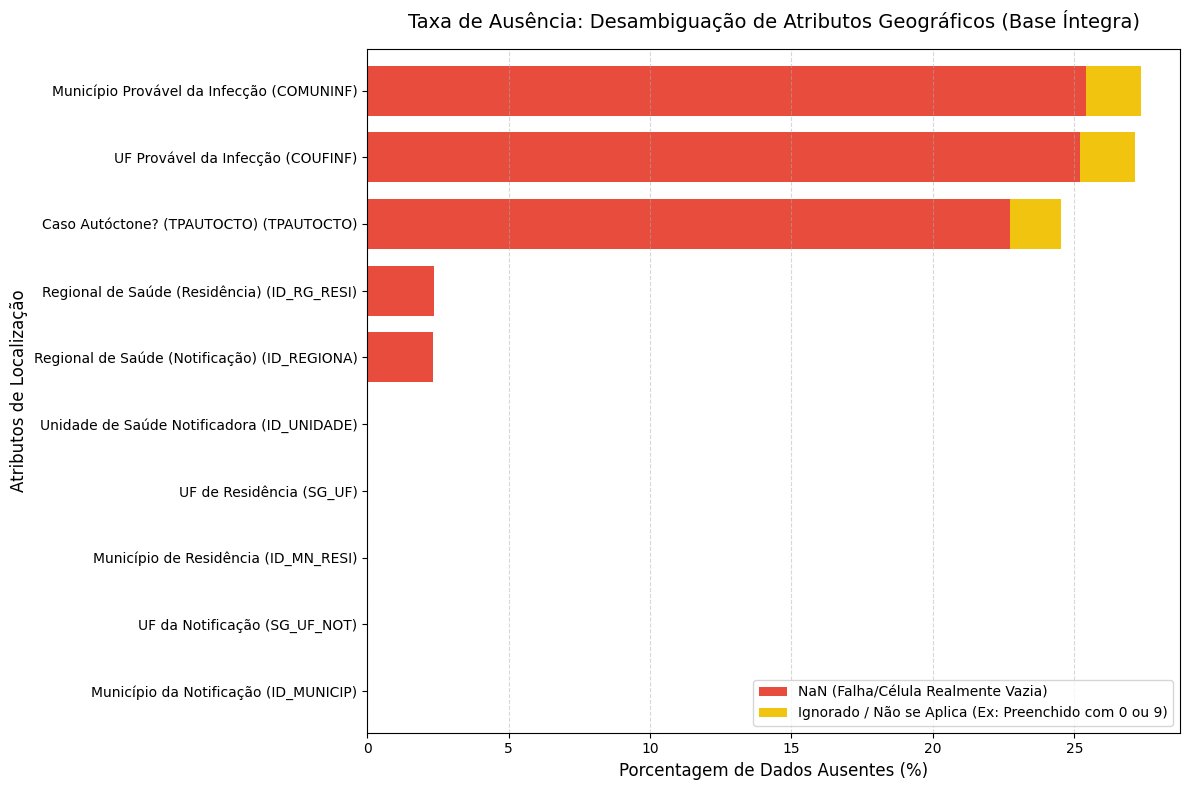

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1. Definindo os 10 atributos exatos solicitados
colunas_geo = [
    'ID_MN_RESI', 'SG_UF', 'ID_RG_RESI',
    'ID_MUNICIP', 'SG_UF_NOT', 'ID_REGIONA', 'ID_UNIDADE',
    'COMUNINF', 'COUFINF', 'TPAUTOCTO'
]

# Dicionário para deixar o gráfico legível
map_geo = {
    'ID_MN_RESI': 'Município de Residência',
    'SG_UF': 'UF de Residência',
    'ID_RG_RESI': 'Regional de Saúde (Residência)',
    'ID_MUNICIP': 'Município da Notificação',
    'SG_UF_NOT': 'UF da Notificação',
    'ID_REGIONA': 'Regional de Saúde (Notificação)',
    'ID_UNIDADE': 'Unidade de Saúde Notificadora',
    'COMUNINF': 'Município Provável da Infecção',
    'COUFINF': 'UF Provável da Infecção',
    'TPAUTOCTO': 'Caso Autóctone? (TPAUTOCTO)'
}

n_linhas = len(df)
dados_geo = []

for col in colunas_geo:
    if col in df.columns:
        # A. Células realmente VAZIAS (NaN real)
        is_nan = df[col].isna()
        nan_perc = (is_nan.sum() / n_linhas) * 100

        # B. Células IGNORADAS ou NÃO SE APLICA (Códigos de preenchimento nulo do DATASUS)
        # Convertendo para string e tirando o '.0' caso o Pandas tenha lido como float
        col_str = df[col].astype(str).str.strip().str.replace(r'\.0$', '', regex=True)

        # O SINAN usa diferentes tamanhos de zeros e noves dependendo do campo (ex: UF=99, Município=000000)
        # Também consideramos espaços em branco " " que não foram pegos pelo isna()
        is_ign = (~is_nan) & (col_str.isin([
            '0', '00', '0000', '00000', '000000',
            '9', '99', '999', '9999', '99999', '999999',
            ''
        ]))

        # Para TPAUTOCTO, o Dicionário diz que 3 é "Indeterminado" (Ignorado)
        if col == 'TPAUTOCTO':
            is_ign = is_ign | ((~is_nan) & (col_str == '3'))

        ign_perc = (is_ign.sum() / n_linhas) * 100

        # Salvando os resultados
        dados_geo.append({
            'Atributo': map_geo.get(col, col) + f" ({col})",
            'NaN (%)': nan_perc,
            'Ignorado / Zerado (%)': ign_perc,
            'Total_Ausente (%)': nan_perc + ign_perc
        })

# 3. Criando o DataFrame e ordenando do mais ausente para o menos ausente
df_geo = pd.DataFrame(dados_geo).sort_values(by='Total_Ausente (%)', ascending=False)

# 4. Print do relatório no console
print("--- RELATÓRIO DE QUALIDADE: VARIÁVEIS GEOGRÁFICAS E NOTIFICAÇÃO ---")
print(df_geo[['Atributo', 'NaN (%)', 'Ignorado / Zerado (%)', 'Total_Ausente (%)']].to_string(index=False))

# 5. Geração do Gráfico de Barras Horizontal
plt.figure(figsize=(12, 8))
df_geo.set_index('Atributo')[['NaN (%)', 'Ignorado / Zerado (%)']].plot(
    kind='barh',
    stacked=True,
    color=['#e74c3c', '#f1c40f'],
    ax=plt.gca(),
    width=0.75
)

plt.title('Taxa de Ausência: Desambiguação de Atributos Geográficos (Base Íntegra)', fontsize=14, pad=15)
plt.xlabel('Porcentagem de Dados Ausentes (%)', fontsize=12)
plt.ylabel('Atributos de Localização', fontsize=12)
plt.legend(['NaN (Falha/Célula Realmente Vazia)', 'Ignorado / Não se Aplica (Ex: Preenchido com 0 ou 9)'], loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.gca().invert_yaxis() # Para deixar o mais ausente no topo do gráfico
plt.tight_layout()
plt.show()

#Remoção de Instâncias onde não existe mn_resi

In [46]:
# Print antes de remover instancias sem municipio
print(f"Shape do dataframe após seleção de colunas: {df.shape}")

# Remover registros sem o código do município de residência
df = df.dropna(subset=['ID_MN_RESI'])

df = df[~df['ID_MN_RESI'].astype(str).str.strip().isin(['0', '000000', ''])]

print(f"Shape do dataframe após remoção de instancias: {df.shape}")

Shape do dataframe após seleção de colunas: (1655637, 121)
Shape do dataframe após remoção de instancias: (1655630, 121)


#Remoção de Instâncias onde SEM Escolaridade e Raça

In [47]:
# Primeiro, converter os códigos de "Ignorado" do SINAN para NaN real (np.nan)
# Isso permite que o dropna() funcione para tudo de uma vez
#valores_ignorados = [9, '9', '09', '99', 'I']
# df.replace(valores_ignorados, np.nan, inplace=True)            >>>>>>>Replace global>>>>>> não pode fazer isso para todos os dados, pois pode dar replace em uma 9 ou 09 ou 99 em uma coluna em que isso é válido

# Print antes da remoção
print(f"Shape inicial: {df.shape}")

# Removemos os NaN e o código 9 (Ignorado)
df = df.dropna(subset=['CS_RACA'])
df = df[~df['CS_RACA'].astype(str).str.replace(r'\.0$', '', regex=True).isin(['9'])]


#colunas_obrigatorias = ['CS_RACA', 'CS_ESCOL_N', 'ID_MN_RESI']              <<<<<<<<<<<<<<<
#df = df.dropna(subset=colunas_obrigatorias)                                 <<<<<<<<<<<<<<<

# Removi os NaN, código 9 (Ignorado) e código 10 (Não se Aplica)
df = df.dropna(subset=['CS_ESCOL_N'])
df = df[~df['CS_ESCOL_N'].astype(str).str.replace(r'\.0$', '', regex=True).isin(['9', '10'])]

# Print após a limpeza completa (NaN + Ignorados)
print(f"Shape final após limpeza (NaN + Ignorados): {df.shape}")

Shape inicial: (1655630, 121)
Shape final após limpeza (NaN + Ignorados): (713428, 121)


#Célula de tratamento de instâncias
#Remoção de atributos

In [61]:


# Carregar Dados da Dengue
#df_head = pd.read_csv('/content/dados_dengue/DENGBR25.csv', sep=',', nrows=1)         >>>>>>>>>>>>>>> Não pode carregar novamente se não perde todo o processamente feito anteriormente
all_cols = df_head.columns.tolist()

exclude_cols = [
    # --- Dados Administrativos e de Notificação ---
    'TP_NOT', 'ID_AGRAVO', 'DT_NOTIFIC', 'SEM_NOT', 'NU_ANO', 'DT_DIGITA',
    'TP_SISTEMA', 'NDUPLIC_N', 'CS_FLXRET', 'FLXRECEBI', 'MIGRADO_W',
    'ID_UNIDADE', 'ID_REGIONA', 'SG_UF_NOT', 'ID_MUNICIP',

    # --- Dados de Sintomas e Comorbidades (Vindos do seu TXT) ---
    'FEBRE', 'MIALGIA', 'CEFALEIA', 'EXANTEMA', 'VOMITO', 'NAUSEA',
    'DOR_COSTAS', 'CONJUNTVIT', 'ARTRITE', 'ARTRALGIA', 'PETEQUIA_N',
    'LEUCOPENIA', 'LACO', 'DOR_RETRO', 'DIABETES', 'HEMATOLOG',
    'HEPATOPAT', 'RENAL', 'HIPERTENSA', 'ACIDO_PEPT', 'AUTO_IMUNE',

    # --- Sinais Clínicos Secundários e Hemorragias ---
    'COMPLICA', 'EVIDENCIA', 'CON_FHD', 'PLASMATICO', 'PLAQ_MENOR',
    'MANI_HEMOR', 'EPISTAXE', 'GENGIVO', 'METRO', 'PETEQUIAS',
    'HEMATURA', 'SANGRAM', 'LACO_N', 'DOENCA_TRA',

    # --- Variáveis de Chikungunya e Exames não Rotineiros ---
    'DT_CHIK_S1', 'DT_CHIK_S2', 'RES_CHIKS1', 'RES_CHIKS2', 'DT_PRNT',
    'RESUL_PRNT', 'DT_VIRAL', 'RESUL_VI_N', 'DT_PCR', 'RESUL_PCR_',
    'DT_SORO', 'RESUL_SORO', 'DT_NS1', 'RESUL_NS1', 'HISTOPA_N', 'IMUNOH_N',

    # --- Geográficos Confusos (Hospitalização e Infecção) ---
    'NM_MUNICIPIO', 'MUNICIPIO', 'UF', 'COMUNINF', 'COUFINF',
    'COPAISINF', 'ID_PAIS',

    # --- Datas Intermediárias e Pessoais ---
    'DT_SIN_PRI', 'SEM_PRI', 'ANO_NASC', 'DT_INVEST', 'DT_ENCERRA',
    'DT_ALRM', 'DT_GRAV', 'DT_INTERNA', 'DT_OBITO',

    # --- Outros (Ajuste Fino) ---
    'CRITERIO', 'CS_GESTANT', 'ID_OCUPA_N'
]

# Vamos garantir que não haja erro se alguma coluna já tiver sido deletada
cols_to_drop = [col for col in exclude_cols if col in df.columns]

# Dropa (joga fora) as colunas indesejadas direto da memória
df = df.drop(columns=cols_to_drop)


#                                                                                           >>>>>>>>>>>> df = pd.read_csv('/content/dados_dengue/DENGBR25.csv', sep=',', usecols=cols_to_read, low_memory=False, dtype={'ID_MN_RESI': str})

print(f"Shape FINAL após seleção dos atributos (Colunas): {df.shape}")

Shape FINAL após seleção dos atributos (Colunas): (713428, 36)


#Transformando base de casos individuais em uma base de municípios

##quais atributos iremos criar?
Os atributos criados são apenas sugestões

Para transformar essa base de casos individuais em uma base de municípios, precisamos aplicar uma técnica chamada Agregação (Group By). Como a maioria dessas variáveis é categórica, a melhor forma de agregá-las é criando taxas e proporções para cada município.